# Read MS csv

## import

In [1]:
import io
import pandas as pd
import numpy as np
from pathlib import Path
# import re  # for debugging

## read csv

In [2]:
# Read the CSV file
file_path = Path('./20260521.csv')  # this should be in the same folder as this script, or provide a complete filepath
assert file_path.is_file(), f"File not found: {file_path}. Please double check the path and filename."
with open(file_path, 'r') as f:
    lines = f.readlines()

# instrument filepath from metadata 
instrument_filepath = lines[0].strip().split(',', 1)[1]  # split on first comma only
print(f"Instrument path: {instrument_filepath}")

Instrument path: D:\MassHunter\Data\ZD\202605\20260520_TigE_activity\QuantResults\20260520_TigE_activity.batch.bin


## find sequence and data table lines in the csv

In [3]:
# find sequence and data tables by looking for "Data File" in the table header row
table_starts = []  # (name_line_index, header_line_index, table_name)
for i, line in enumerate(lines):
    if line.strip().startswith('Data File'):
        table_starts.append((i - 1, i, lines[i - 1].strip().strip(',')))  # name row is the line just before

# find table names and print for checking 
table_names = [table_name for _, _, table_name in table_starts]
print(f"Found {len(table_starts)} tables {table_names} at indices:")
max_width = max(len(name) for name in table_names) + 2
for name_idx, header_idx, table_name in table_starts:
    print(f"  {table_name:<{max_width}} : {header_idx}")

Found 4 tables ['Sequence Table', 'Methionine', '5dA', '5 MTA'] at indices:
  Sequence Table   : 4
  Methionine       : 118
  5dA              : 176
  5 MTA            : 234


## parse into dataframes and clean

In [4]:
tables = {}

# parse into however many tables 
for t, (name_idx, header_idx, name) in enumerate(table_starts):
    end_idx = table_starts[t + 1][0] if t + 1 < len(table_starts) else len(lines)  # find last line of each table 
    chunk = ''.join(lines[header_idx:end_idx])  # add the header line in 
    # debugging print statements 
    # print(f"--- {name} ---")
    # print(repr(chunk[:200]))  # show raw first 200 chars including escape characters
    # first_line = chunk.split('\n')[0]
    # print(f"{name}: {repr(first_line)}")
    # print()
    tables[name] = pd.read_csv(io.StringIO(chunk), 
                               header=0, 
                               skip_blank_lines=True,
                               na_values=['ND']
                               ).dropna(how='all')

# if any columns aren't returning the right data type 
debug = 0
if debug:
    print("debugging")
    for name, table in tables.items():
        for col in table.columns:
            if pd.api.types.is_string_dtype(table[col]) and col not in ['Data File', 'Type', 'ISTD', 'Name', 'Acq. Method File']:
                non_numeric = table[col].dropna()
                non_numeric = non_numeric[pd.to_numeric(non_numeric, errors='coerce').isna()]
                if len(non_numeric) > 0:
                    values = ', '.join(f"'{v}'" for v in non_numeric.unique())
                    print(f"{name} — '{col}': {values}")
    print("\n")

# show head of each table to check 
for name, table in tables.items():
    print(f"--- {name} (first five rows) ---")
    display(table.head())
    if debug:
        print("Confirm all table data with numbers are float64, not str. Otherwise add NA values to na_values=['ND'] in pd.read_csv() call")
        print(table.dtypes)
    print()

--- Sequence Table (first five rows) ---


,Data File,Name,Type,Vial,Vol.,Level,Acq. Method File
0,01.d,1 blank,Blank,NaN,3,NaN,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m
1,02.d,2 blank,Blank,NaN,3,NaN,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m
2,03.d,3 std 0,Cal,NaN,3,1.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m
3,04.d,4 std 0.5,Cal,NaN,3,2.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m
4,05.d,5 std 1,Cal,NaN,3,3.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m



--- Methionine (first five rows) ---


,Data File,Type,ISTD,RT,Resp.,ISTD Resp,RR,Final Conc.,Exp. Conc.,Accuracy
0,01.d,Blank,Trp,1.269,5.0,3.0,1.435928,33.4347,NaN,NaN
1,02.d,Blank,Trp,1.208,17.0,3.0,6.038097,102.8388,NaN,NaN
2,03.d,Cal,Trp,1.147,33.0,23134.0,0.001418,0.1936,0.0,NaN
3,04.d,Cal,Trp,1.244,133.0,21161.0,0.006266,0.3294,0.5,65.9
4,05.d,Cal,Trp,1.232,597.0,21004.0,0.028445,0.9480,1.0,94.8



--- 5dA (first five rows) ---


,Data File,Type,ISTD,RT,Resp.,ISTD Resp,RR,Final Conc.,Exp. Conc.,Accuracy
0,01.d,Blank,Trp,2.171,1.0,3.0,0.383417,0.7167,NaN,NaN
1,02.d,Blank,Trp,2.147,11.0,3.0,4.125648,8.0064,NaN,NaN
2,03.d,Cal,Trp,2.171,53.0,23134.0,0.002279,0.0263,0.0,NaN
3,04.d,Cal,Trp,2.123,5182.0,21161.0,0.244869,0.4648,0.5,93.0
4,05.d,Cal,Trp,2.123,11756.0,21004.0,0.559699,1.0389,1.0,103.9



--- 5 MTA (first five rows) ---


,Data File,Type,ISTD,RT,Resp.,ISTD Resp,RR,Final Conc.,Exp. Conc.,Accuracy
0,01.d,Blank,Trp,3.336,48.0,3.0,15.080300,8.2317,NaN,NaN
1,02.d,Blank,Trp,3.348,62.0,3.0,22.169297,13.3099,NaN,NaN
2,03.d,Cal,Trp,3.324,160.0,23134.0,0.006928,0.0000,0.0,NaN
3,04.d,Cal,Trp,3.324,25580.0,21161.0,1.208838,0.3672,0.5,73.4
4,05.d,Cal,Trp,3.324,59052.0,21004.0,2.811478,1.1832,1.0,118.3


## rename columns and pivot

In [5]:
# Split sequence and data table names for separate processing
sequence_table_name = table_names[0]
data_table_names = table_names[1:]

# Rename columns in data tables with their table name as prefix
skip_cols = ['Type', 'ISTD']
double_rename = False
for name, table in tables.items():
    if name != sequence_table_name:
        try:
            tables[name] = table.drop(columns=skip_cols)
        except KeyError:
            double_rename = True 
            pass
if double_rename:
    print("Note: you may have doubly renamed your data tables. If you see something like \"Methionine_Methionine_RT\" \n" 
          "in your column names, run the cell \"parse into dataframes and clean\" above and then this cell again.\n")

for table_name in data_table_names:
    tables[table_name].columns = [f'{table_name}_{col}' if col != 'Data File' else 'Data File' for col in tables[table_name].columns]
# to check column renaming: 
# print("Renamed columns in data tables:")
# for table_name in data_table_names:
#     print(f"  {table_name}: {tables[table_name].columns.tolist()}")
# print()

# Merge data tables into the sequence table, matching on the 'Data File' column
final_df = tables[sequence_table_name]
for name in data_table_names:
    final_df = final_df.merge(tables[name], on='Data File', how='left')

# Remove any remaining blank rows
final_df = final_df.dropna(how='all')

# print("Column names:")
# print(final_df.columns.tolist())
print(f"Sequence table rows: {len(tables[sequence_table_name])}")
print(f"Data tables rows: {[len(tables[name]) for name in data_table_names]}")
print(f"Final dataframe shape (rows, cols): {final_df.shape}")
if final_df.shape[0] != len(tables[sequence_table_name]):
    print("Warning: final dataframe row count does not match sequence table row count. Check for merge issues.")
else:
    print("Row count matches sequence table row count, looks good.")
print(f"Target compounds in table: {data_table_names}")
print(f"First few rows:")
pd.set_option('display.max_columns', None)
display(final_df.head(10))
# print("Full dataframe:")
# display(final_df)

Sequence table rows: 56
Data tables rows: [56, 56, 56]
Final dataframe shape (rows, cols): (56, 28)
Row count matches sequence table row count, looks good.
Target compounds in table: ['Methionine', '5dA', '5 MTA']
First few rows:


,Data File,Name,Type,Vial,Vol.,Level,Acq. Method File,Methionine_RT,Methionine_Resp.,Methionine_ISTD Resp,Methionine_RR,Methionine_Final Conc.,Methionine_Exp. Conc.,Methionine_Accuracy,5dA_RT,5dA_Resp.,5dA_ISTD Resp,5dA_RR,5dA_Final Conc.,5dA_Exp. Conc.,5dA_Accuracy,5 MTA_RT,5 MTA_Resp.,5 MTA_ISTD Resp,5 MTA_RR,5 MTA_Final Conc.,5 MTA_Exp. Conc.,5 MTA_Accuracy
0,01.d,1 blank,Blank,NaN,3,NaN,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.269,5.0,3.0,1.435928,33.4347,NaN,NaN,2.171,1.0,3.0,0.383417,0.7167,NaN,NaN,3.336,48.0,3.0,15.080300,8.2317,NaN,NaN
1,02.d,2 blank,Blank,NaN,3,NaN,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.208,17.0,3.0,6.038097,102.8388,NaN,NaN,2.147,11.0,3.0,4.125648,8.0064,NaN,NaN,3.348,62.0,3.0,22.169297,13.3099,NaN,NaN
2,03.d,3 std 0,Cal,NaN,3,1.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.147,33.0,23134.0,0.001418,0.1936,0.00,NaN,2.171,53.0,23134.0,0.002279,0.0263,0.00,NaN,3.324,160.0,23134.0,0.006928,0.0000,0.00,NaN
3,04.d,4 std 0.5,Cal,NaN,3,2.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.244,133.0,21161.0,0.006266,0.3294,0.50,65.9,2.123,5182.0,21161.0,0.244869,0.4648,0.50,93.0,3.324,25580.0,21161.0,1.208838,0.3672,0.50,73.4
4,05.d,5 std 1,Cal,NaN,3,3.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.232,597.0,21004.0,0.028445,0.9480,1.00,94.8,2.123,11756.0,21004.0,0.559699,1.0389,1.00,103.9,3.324,59052.0,21004.0,2.811478,1.1832,1.00,118.3
5,06.d,6 std 2,Cal,NaN,3,4.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.232,1532.0,19362.0,0.079118,2.3435,2.00,117.2,2.135,23894.0,19362.0,1.234048,2.2888,2.00,114.4,3.324,113959.0,19362.0,5.885582,2.8055,2.00,140.3
6,07.d,7 std 3.33,Cal,NaN,3,5.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.232,2401.0,18750.0,0.128073,3.6693,3.33,110.2,2.098,37592.0,18750.0,2.004903,3.7533,3.33,112.7,3.324,168064.0,18750.0,8.963344,4.5152,3.33,135.6
7,08.d,8 std 5,Cal,NaN,3,6.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.232,3638.0,18047.0,0.201566,5.6205,5.00,112.4,2.098,54319.0,18047.0,3.009873,5.7250,5.00,114.5,3.324,214592.0,18047.0,11.890784,6.2345,5.00,124.7
8,09.d,9 std 10,Cal,NaN,3,7.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.232,7212.0,17318.0,0.416426,11.0826,10.00,110.8,2.111,98120.0,17318.0,5.665796,11.3413,10.00,113.4,3.324,337209.0,17318.0,19.471672,11.2509,10.00,112.5
9,10.d,10 std 20,Cal,NaN,3,8.0,ExtendC18_MRM_5dA Met 5MTA_Trp ISTD.m,1.232,15466.0,16763.0,0.922663,22.7979,20.00,114.0,2.123,175289.0,16763.0,10.457054,23.7746,20.00,118.9,3.324,542569.0,16763.0,32.367516,24.1033,20.00,120.5


# Plot data

## import

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
plt.rcParams["font.weight"] = "bold"  # Bolds general text (titles, etc.)
plt.rcParams["axes.labelweight"] = "bold"  # Bolds x and y axis labels

## Standard curves

## Data

### set plot title, legend, and colors

Current plot titles:
20260521_TigE activity assay_{compound}_{RR or conc}.png
Change "assay_title" in cell above to update

copy+paste dictionaries into cell below and edit

label_map_dict = {
    'all': 'all',
    'noenz': 'noenz',
    'nosam': 'nosam',
    'nosub': 'nosub',
    'noti': 'noti',
}

Colormap: tab10
color_map_dict = {
    'all': '#1f77b4',
    'noenz': '#ff7f0e',
    'nosam': '#2ca02c',
    'nosub': '#d62728',
    'noti': '#9467bd',
}


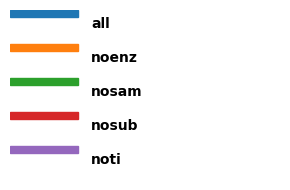

Colormap: Set1
color_map_dict = {
    'all': '#e41a1c',
    'noenz': '#377eb8',
    'nosam': '#4daf4a',
    'nosub': '#984ea3',
    'noti': '#ff7f00',
}


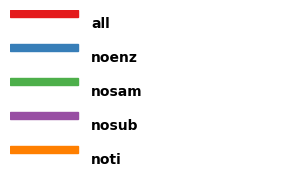

Colormap: Set2
color_map_dict = {
    'all': '#66c2a5',
    'noenz': '#fc8d62',
    'nosam': '#8da0cb',
    'nosub': '#e78ac3',
    'noti': '#a6d854',
}


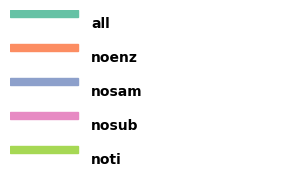

Colormap: Paired
color_map_dict = {
    'all': '#a6cee3',
    'noenz': '#1f78b4',
    'nosam': '#b2df8a',
    'nosub': '#33a02c',
    'noti': '#fb9a99',
}


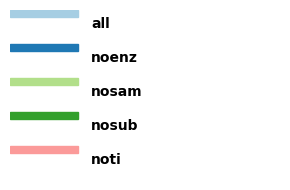

In [7]:
# Filter data for samples (not blanks or calibration standards)
samples_df = final_df[(final_df['Type'] == 'Sample') & (~final_df['Name'].str.contains('water', case=False, na=False))].copy()

# Parse the Name column to extract index, condition, and time
samples_df[['index', 'condition', 'time']] = samples_df['Name'].str.split(expand=True, n=2)
conditions = sorted(samples_df['condition'].dropna().unique())
samples_df['time'] = pd.to_numeric(samples_df['time'], errors='coerce')

# set name for figures
assay_title = "TigE activity assay"
sample_out_png = str(file_path)[:-4].split('/',)[-1] + "_" + assay_title + '_{compound}_{RR or conc}.png'
print(f"Current plot titles:\n{sample_out_png}\nChange \"assay_title\" in cell above to update\n")

print("copy+paste dictionaries into cell below and edit\n")
print("label_map_dict = {")
for cond in conditions:
    print(f"    '{cond}': '{cond}',")
print("}")
print()

possible_colormaps = ['tab10', 'Set1', 'Set2', 'Paired']  # consider tab10, Set1, Set2, Paired
# Display swatches and copyable dict
for color in possible_colormaps:
    cmap = plt.colormaps[color]  
    color_map_dict = {cond: mcolors.to_hex(cmap(i)) for i, cond in enumerate(conditions)}
    print(f"Colormap: {color}")
    print("color_map_dict = {")  # print copyable dict
    for cond, hex_color in color_map_dict.items():
        print(f"    '{cond}': '{hex_color}',")
    print("}")
    color_map_dict = {cond: mcolors.to_hex(cmap(i)) for i, cond in enumerate(conditions)}
    fig, ax = plt.subplots(figsize=(3, len(conditions) * 0.4))
    for i, (cond, hex_color) in enumerate(color_map_dict.items()):
        ax.add_patch(mpatches.Rectangle((0, i), 1, 0.2, color=hex_color))
        ax.text(1.2, i + 0.4, cond, va='center')
    ax.set_xlim(0, 4)
    ax.set_ylim(0, len(conditions))
    ax.axis('off')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

### plot and optionally save

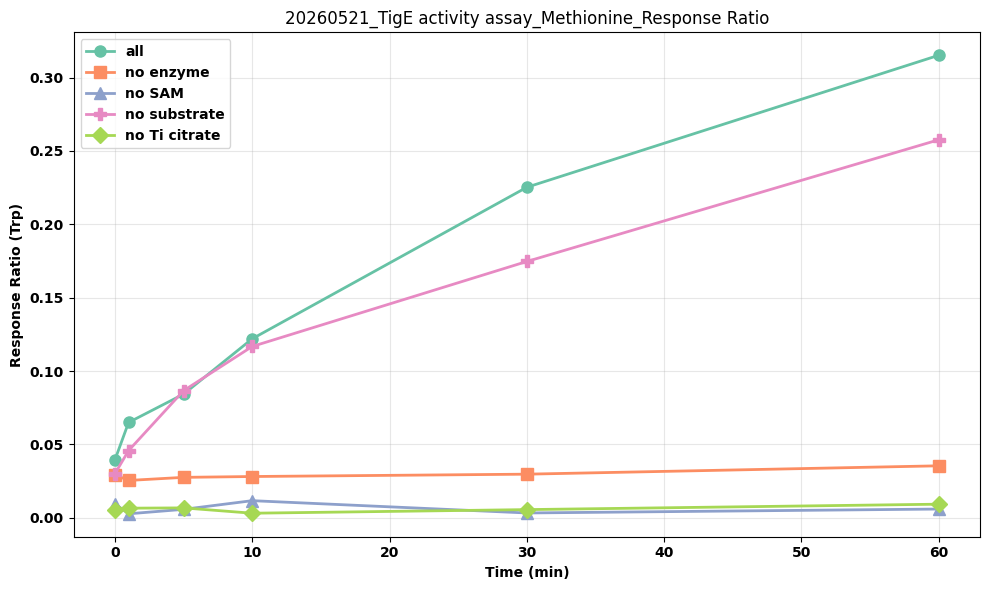

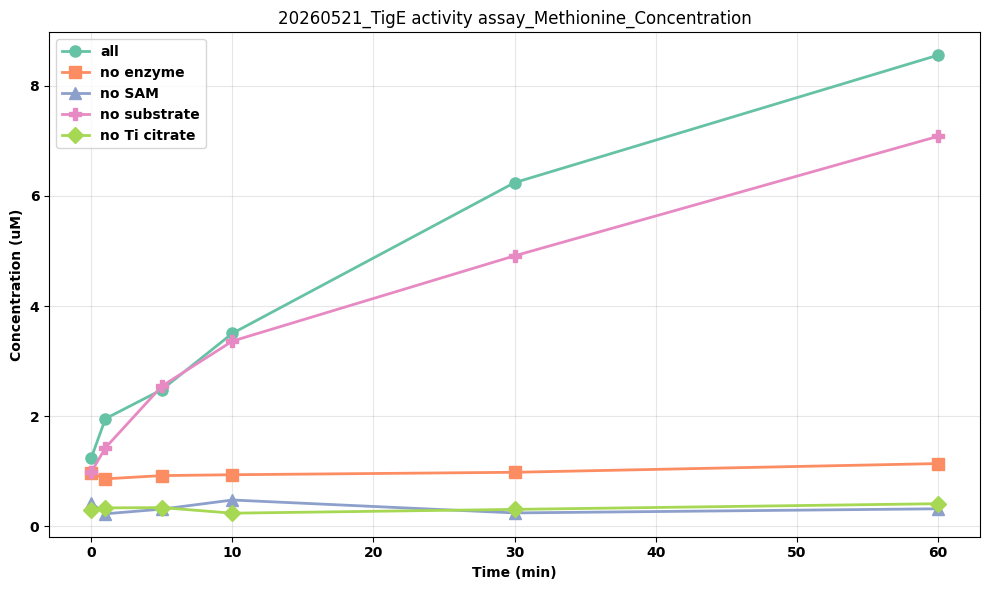

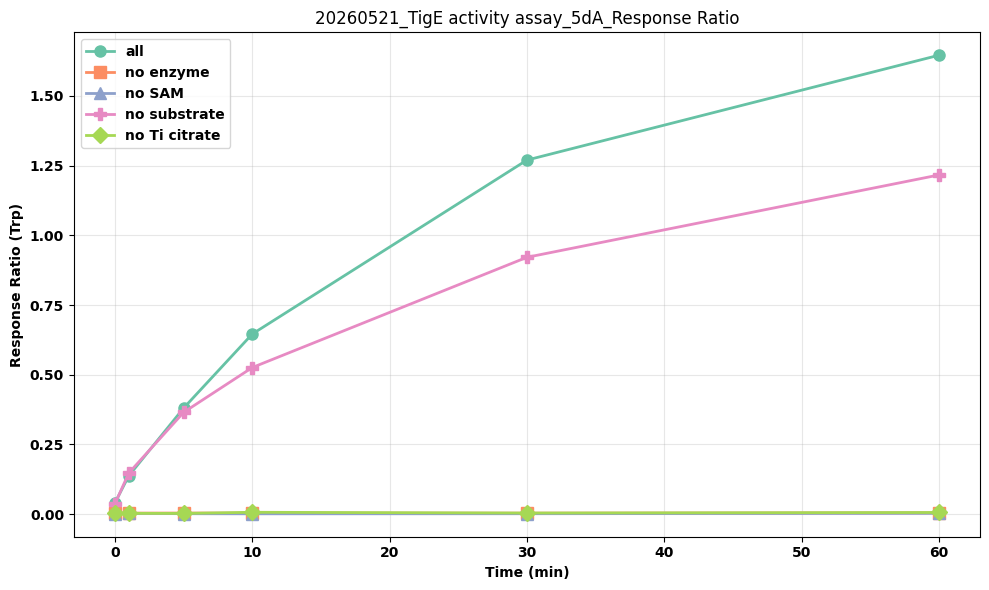

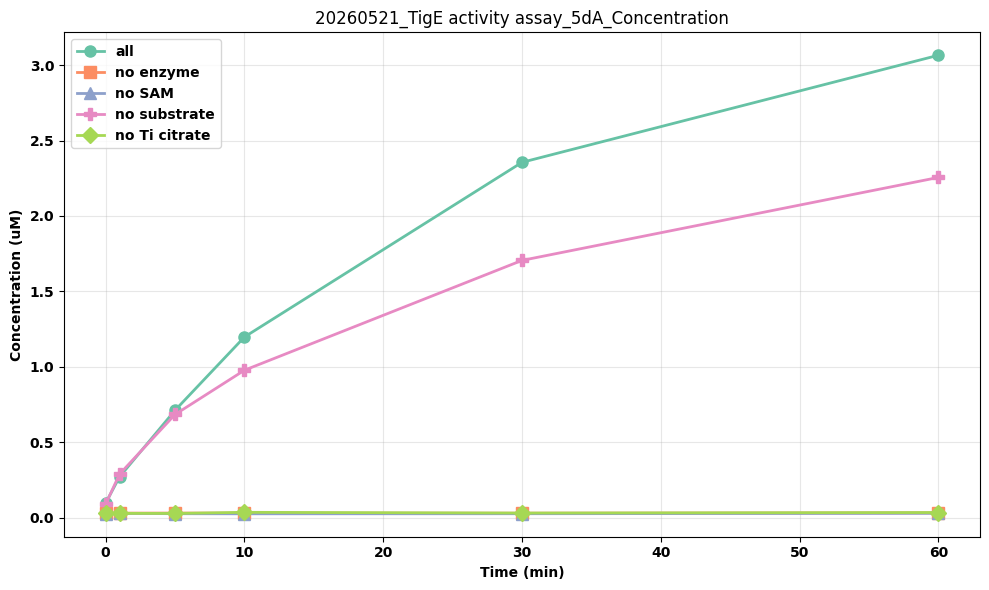

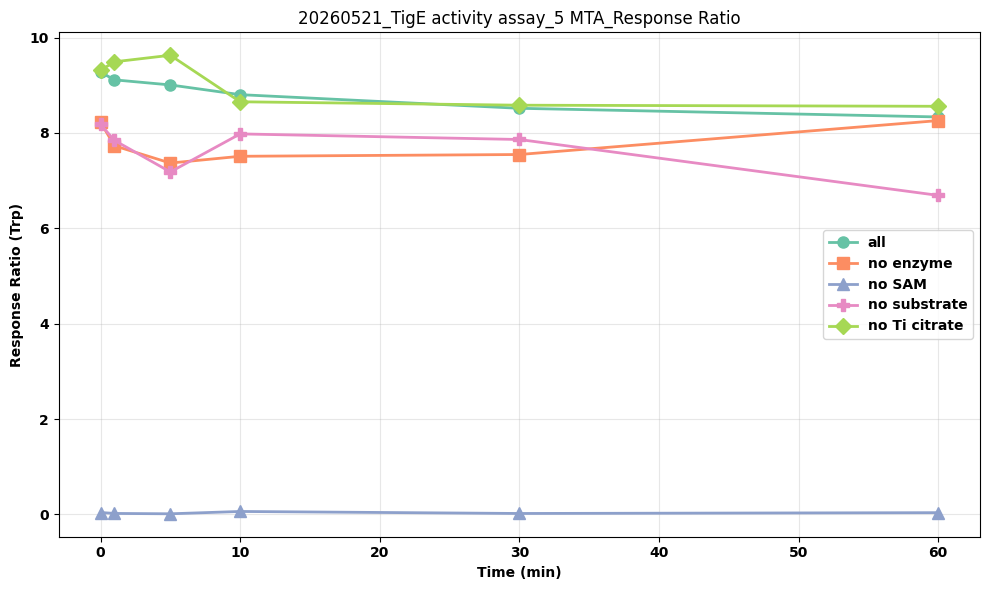

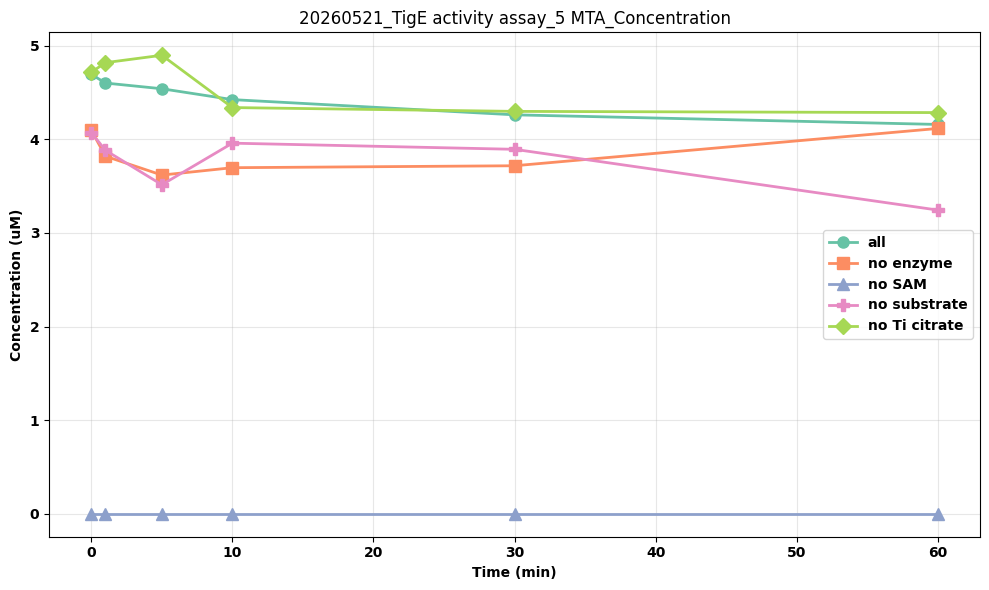

In [10]:
save_plots = 0  # set to True once you're ready to save output pngs
plot_RR = 1 
plot_conc = 1

label_map_dict = {
    'all': 'all',
    'noenz': 'no enzyme',
    'nosam': 'no SAM',
    'nosub': 'no substrate',
    'noti': 'no Ti citrate',
}

color_map_dict = {
    'all': '#66c2a5',
    'noenz': '#fc8d62',
    'nosam': '#8da0cb',
    'nosub': '#e78ac3',
    'noti': '#a6d854',
}

# o circle, s square, ^ triangle_up, P plus_filled, D diamond, X x_filled, v triangle_down, d thin diamond, * star, h hexagon 
markers = ['o', 's', '^', 'P', 'D', 'X', 'v']  # in the same order as conditions 
marker_dict = {cond: markers[i % len(markers)] for i, cond in enumerate(conditions)}

# Create plots for each compound
for compound in data_table_names:
    rr_col = f'{compound}_RR'
    conc_col = f'{compound}_Final Conc.'
    
    plots = []
    if plot_RR:
        plots.append((rr_col, 'Response Ratio'))
    if plot_conc:
        plots.append((conc_col, 'Concentration'))

    for col, ylabel in plots:
        fig, ax = plt.subplots(figsize=(10, 6))
        for condition in conditions:
            condition_data = samples_df[samples_df['condition'] == condition].sort_values('time')
            ax.plot(
                condition_data['time'],
                condition_data[col],
                marker=marker_dict[condition],
                color=color_map_dict[condition],
                label=label_map_dict[condition],
                linewidth=2,
                markersize=8
            )
        title = f"{file_path.stem}_{assay_title}_{compound}_{ylabel}"
        ax.set_xlabel('Time (min)')
        if "response".lower() in ylabel.lower():
            ax.set_ylabel("Response Ratio (Trp)")
        elif "conc".lower() in ylabel.lower():
            ax.set_ylabel("Concentration (uM)")
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        # print(title)
        if save_plots:
            fig.savefig(f"{title}.png", dpi=1500)
        plt.show()